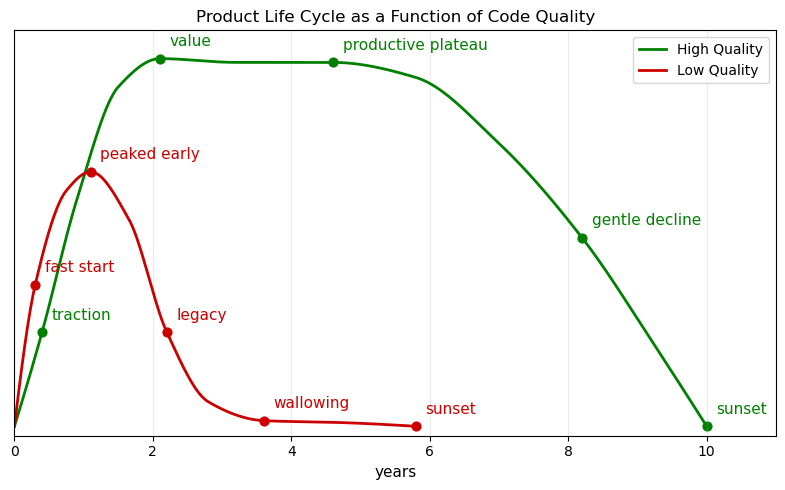

'software_lifecycle_diagram_v2.png'

In [3]:
import io
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
import numpy as np

csv_data = """
project,t,y,label
Healthy,0.0,0.05,
Healthy,0.4,0.55,traction
Healthy,0.9,1.25,
Healthy,1.5,1.85,
Healthy,2.1,2.00,value
Healthy,3.2,1.98,
Healthy,4.6,1.98,productive plateau
Healthy,5.8,1.90,
Healthy,7.0,1.55,
Healthy,8.2,1.05,gentle decline
Healthy,9.3,0.45,
Healthy,10.0,0.05,sunset
Unhealthy,0.0,0.05,
Unhealthy,0.30,0.8,fast start
Unhealthy,0.75,1.30,
Unhealthy,1.1,1.4,peaked early
Unhealthy,1.65,1.15,
Unhealthy,2.20,0.55,legacy
Unhealthy,2.80,0.18,
Unhealthy,3.60,0.08,wallowing
Unhealthy,4.70,0.07,
Unhealthy,5.80,0.05,sunset
"""

df = pd.read_csv(io.StringIO(csv_data.strip()))

fig, ax = plt.subplots(figsize=(8, 5))

colors = {
    "Healthy": "green",
    "Unhealthy": "#CC0000",
}

labels = {
    "Healthy": "High Quality",
    "Unhealthy": "Low Quality",
}

for project, group in df.groupby("project", sort=False):
    group = group.sort_values("t")
    x = group["t"].to_numpy()
    y = group["y"].to_numpy()

    interpolator = PchipInterpolator(x, y)
    xs = np.linspace(x.min(), x.max(), 500)
    ys = interpolator(xs)

    ax.plot(xs, ys, linewidth=2, color=colors[project], label=labels[project])

    labeled = group[group["label"].fillna("").str.len() > 0]
    for _, row in labeled.iterrows():
        ax.scatter(row["t"], row["y"], color=colors[project], s=40)
        ax.annotate(
            row["label"],
            xy=(row["t"], row["y"]),
            xytext=(7, 9),
            textcoords="offset points",
            color=colors[project],
            fontsize=11,
        )

ax.set_title("Product Life Cycle as a Function of Code Quality")
ax.set_xlabel("years", fontsize=11)
ax.set_ylabel("")
ax.set_yticks([])
ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False)

ax.set_xlim(0, 11)
ax.set_ylim(0, 2.15)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.25)

fig.tight_layout()

output_path = "software_lifecycle_diagram_v2.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

output_path
